In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import geopandas as gpd
import os
import cmocean.cm as cmo
import rasterio
import rasterio.plot as rplt
import app
import string
from affine import Affine
from rasterio.io import MemoryFile
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from shapely.geometry import Point

# 0. Import

In [3]:
data_folder = r"D:\[Code]\HydrofractureShackleton_2023\data"
data_dmg_folder = r"D:\[Code]\HydrofractureShackleton_2023\data-dmg"
data_img_folder = r"D:\[Code]\HydrofractureShackleton_2023\data-img"
figure_folder = r"D:\[Code]\HydrofractureShackleton_2023\figures"

In [4]:
path = os.path.join(data_folder, r"shackleton_hydrofractures.xlsx")
events_raw = pd.read_excel(path, index_col=0)
events_raw["geometry"] = gpd.GeoSeries.from_wkt(events_raw["geometry"])
events = gpd.GeoDataFrame(events_raw, geometry="geometry")  # type: ignore
events.set_crs("EPSG:4326", inplace=True)
events.sort_values("lon", inplace=True)
events.reset_index(drop=True, inplace=True)
events.to_crs("EPSG:3031", inplace=True)
events["label"] = list(string.ascii_uppercase)[: len(events)]
events["summer"] = [app.determine_antarctic_summer(d) for d in events["date-0 vis"]]
events["volume-1 m^3"] = np.nan_to_num(x=events["volume-1 m^3"].values, nan=0)  # type: ignore

In [71]:
events_dict = {
    k1: v1
    for k1, v1 in zip(
        [2018, 2019, 2020],
        [
            {
                k: v
                for k, v in zip(
                    events.query("summer == @s")["label"],
                    events.query("summer == @s")["geometry"],
                )
            }
            for s in [2018, 2019, 2020]
        ],
    )
}
events_dict

{2018: {'D': <POINT (2553811.141 -349000.031)>,
  'H': <POINT (2573198.245 -400554.728)>},
 2019: {'A': <POINT (2556275.678 -254610.402)>,
  'B': <POINT (2557205.807 -256922.905)>,
  'C': <POINT (2558699.399 -258069.242)>,
  'E': <POINT (2553680.541 -348994.998)>,
  'F': <POINT (2563306.902 -364995.272)>,
  'G': <POINT (2640302.345 -394293.286)>,
  'I': <POINT (2570620.937 -400879.439)>,
  'J': <POINT (2573243.364 -401593.846)>,
  'K': <POINT (2577450.447 -441465.448)>,
  'L': <POINT (2557013.702 -440962.258)>,
  'M': <POINT (2556055.907 -444050.452)>,
  'O': <POINT (2583759.64 -477793.211)>,
  'P': <POINT (2551956.42 -473217.002)>,
  'Q': <POINT (2576277.364 -480348.518)>},
 2020: {'N': <POINT (2558789.241 -471302.443)>}}

In [72]:
optical_files = [
    f
    for f in os.listdir(data_img_folder)
    if f.endswith(".tif") and f.split("_")[0] == "Optical"
]
sar_files = [
    f
    for f in os.listdir(data_img_folder)
    if f.endswith(".tif") and f.split("_")[0] == "Draining"
]

In [138]:
keys = ["lat", "lon", "Timestamp", "satellite", "file"]
metas = []
for f in optical_files:

    meta_info = f.split("_")[6:9] + [f.split("_")[9].split(".")[0]]
    meta_info[0] = float(meta_info[0])  # type: ignore
    meta_info[1] = float(meta_info[1])  # type: ignore
    meta_info[2] = pd.Timestamp(int(meta_info[2]), unit="ms")  # type: ignore
    meta_info.append(f)
    meta = {k: v for k, v in zip(keys, meta_info)}
    metas.append(meta)
optical = pd.DataFrame(metas)
optical["geometry"] = optical.apply(lambda row: Point(row["lon"], row["lat"]), axis=1)
optical = gpd.GeoDataFrame(optical, geometry="geometry")  # type: ignore
optical.set_crs("EPSG:4326", inplace=True)
optical.to_crs("EPSG:3031", inplace=True)
optical.sort_values("lon", inplace=True)
optical.reset_index(drop=True, inplace=True)
optical["summer"] = [app.determine_antarctic_summer(d) for d in optical["Timestamp"]]

In [166]:
def get_closest_label(point: Point, event_dict: dict) -> str:
    distances = {label: point.distance(geom) for label, geom in event_dict.items()}
    return min(distances, key=distances.get)

def get_closest_distance(point: Point, event_dict: dict) -> str:
    distances = {label: point.distance(geom) for label, geom in event_dict.items()}
    return min(distances.values())


def apply_closest_label(row: pd.Series, event_dict: dict) -> str:
    return get_closest_label(row["geometry"], event_dict[row["summer"]])


def apply_closest_distance(row: pd.Series, event_dict: dict) -> str:
    return get_closest_distance(row["geometry"], event_dict[row["summer"]])


optical_grouped = optical.groupby("geometry").first()
optical_grouped.reset_index(inplace=True)
optical_grouped["number"] = range(len(optical_grouped))
optical_grouped["label"] = np.nan
optical_grouped["distance"] = np.nan
optical_grouped["label"] = optical_grouped.apply(
    lambda row: apply_closest_label(row, events_dict), axis=1
)
optical_grouped["distance"] = optical_grouped.apply(
    lambda row: apply_closest_distance(row, events_dict), axis=1
)
optical_grouped.loc[optical_grouped["distance"] >= 10, "label"] = "X"
optical_grouped.loc[optical_grouped["distance"] >= 10, "distance"] = "9999"
combined = pd.merge(
    optical,
    optical_grouped[["geometry", "label", "distance", "number"]],
    left_on="geometry",
    right_on="geometry",
    how="left",
)
combined

,lat,lon,Timestamp,satellite,file,geometry,summer,label,distance,number
0,-66.671197,95.688052,2019-12-04 02:56:28.269,S2,Optical_clipped_HydrofracturingEvents_2020_Sha...,POINT (2556275.973 -254611.917),2019,A,1.544096,12
1,-66.671197,95.688052,2020-02-22 02:56:30.764,S2,Optical_clipped_HydrofracturingEvents_2020_Sha...,POINT (2556275.973 -254611.917),2019,A,1.544096,12
2,-66.671197,95.688052,2020-02-19 02:46:32.836,S2,Optical_clipped_HydrofracturingEvents_2020_Sha...,POINT (2556275.973 -254611.917),2019,A,1.544096,12
3,-66.671197,95.688052,2020-01-30 02:46:28.983,S2,Optical_clipped_HydrofracturingEvents_2020_Sha...,POINT (2556275.973 -254611.917),2019,A,1.544096,12
4,-66.671197,95.688052,2020-01-13 02:56:28.641,S2,Optical_clipped_HydrofracturingEvents_2020_Sha...,POINT (2556275.973 -254611.917),2019,A,1.544096,12
...,...,...,...,...,...,...,...,...,...,...
151,-66.214001,100.561598,2020-01-31 02:16:27.263,S2,Optical_clipped_HydrofracturingEvents_2020_Sha...,POINT (2576277.038 -480350.162),2019,Q,1.675618,5
152,-66.214001,100.561598,2020-03-01 02:16:32.159,S2,Optical_clipped_HydrofracturingEvents_2020_Sha...,POINT (2576277.038 -480350.162),2019,Q,1.675618,5
153,-66.214001,100.561598,2020-03-11 02:16:32.730,S2,Optical_clipped_HydrofracturingEvents_2020_Sha...,POINT (2576277.038 -480350.162),2019,Q,1.675618,5
154,-66.214001,100.561598,2020-03-14 02:26:30.107,S2,Optical_clipped_HydrofracturingEvents_2020_Sha...,POINT (2576277.038 -480350.162),2019,Q,1.675618,5


2020 2 (39, 10)
2020 1 (20, 10)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
d:\[Code]\

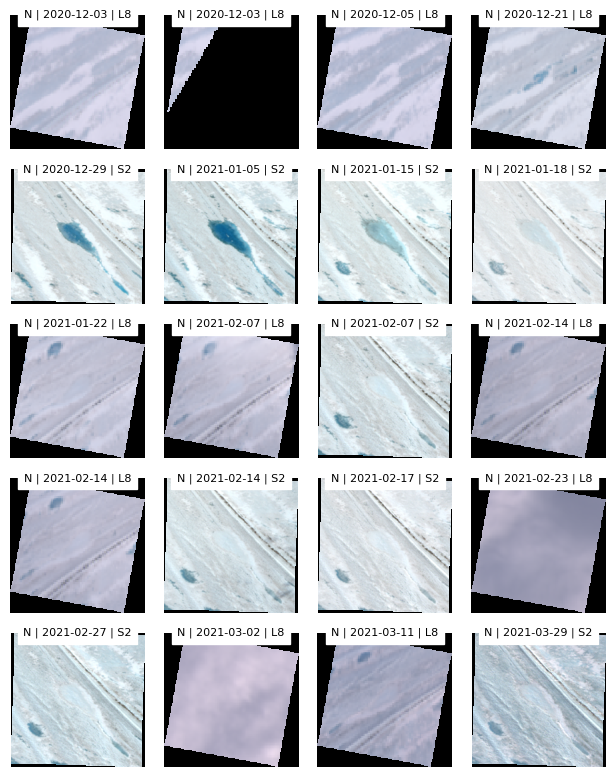

2020 0 (19, 10)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

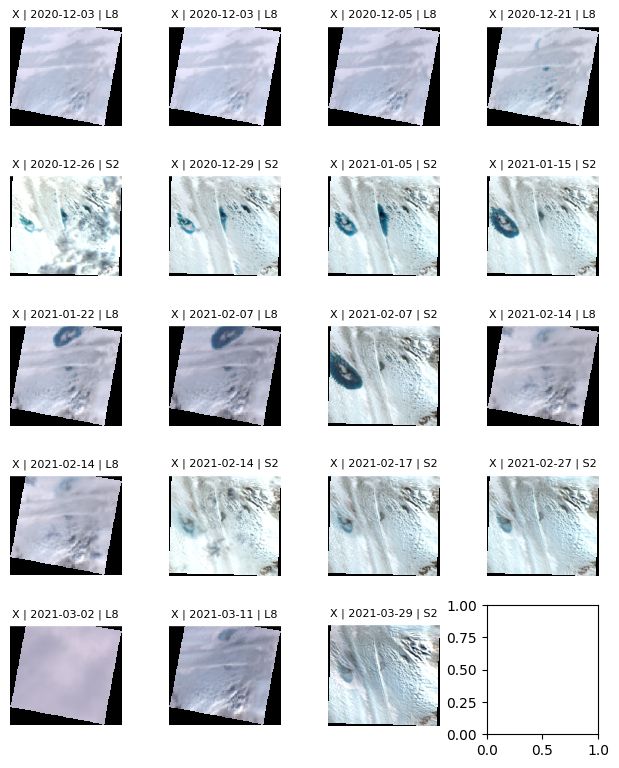

In [168]:
number_cols = 4
size = 4
for summer in [2020]:

    combined_summer = combined.query(f"summer == {summer}")
    
    print(summer, combined_summer.number.nunique(), combined_summer.shape)

    for i, number in enumerate(combined_summer["number"].unique()):
        
        combined_event = combined_summer.query(f"number == @number").copy()
        combined_event.sort_values("Timestamp", inplace=True)
        print(summer, number, combined_event.shape)


        total = combined_event.shape[0]
        number_rows = total // number_cols
        if total % number_cols != 0:
            number_rows += 1
        fig, axes = plt.subplots(number_rows, number_cols, figsize=((size * number_cols) / 2.54, (size * number_rows) / 2.54))

        for j in range(combined_event.shape[0]):
            ax = axes.ravel()[j]
            ax.axis("off")
            with rasterio.open(
                os.path.join(data_img_folder, combined_event["file"].values[j])
            ) as src:
                img = src.read()
                rplt.show(img, transform=src.transform, ax=ax)
            ax.text(
                x = 0.5,
                y = 1,
                s =  combined_event["label"].values[j] + " | " + combined_event["Timestamp"]
                .dt.strftime("%Y-%m-%d")
                .values[j] + " | " + combined_event["satellite"].values[j],
                ha="center",
                va="center",
                fontsize=8,
                color="black",
                bbox={"facecolor":"white", "alpha":1, "edgecolor":"white"},
                transform = ax.transAxes,
            )
        plt.tight_layout()
        fig.savefig(os.path.join(figure_folder, f"optical_{summer}_{number}_{combined_event['label'].values[j]}_{combined_event['lat'].values[j]}_{combined_event['lon'].values[j]}.png"), dpi=300)
        plt.show()